In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\user\Downloads\churn_dataset_100k_messy.csv")

In [3]:
df.head()

,customer_id,tenure_months,monthly_charges,total_charges,contract_type,payment_method,internet_service,support_tickets_3m,last_login_days,promo_discount_pct,churn
0,CUST0000001,6,71.2,450.48,Month-to-month,Electronic check,Fiber optic,1,6.0,8.3,1
1,CUST0000002,56,48.67,2434.29,Two year,Electronic check,DSL,2,6.0,7.3,0
2,CUST0000003,47,81.48,NaN,Month-to-month,Electronic check,DSL,2,15.0,5.7,0
3,CUST0000004,32,74.26,2039.32,Month-to-month,Bank transfer (automatic),Fiber optic,2,3.0,15.8,0
4,CUST0000005,31,64.54,1888.86,Month-to-month,Electronic check,Fiber optic,4,21.0,6.9,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100700 entries, 0 to 100699
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   customer_id         100700 non-null  object 
 1   tenure_months       100700 non-null  int64  
 2   monthly_charges     99734 non-null   object 
 3   total_charges       97657 non-null   object 
 4   contract_type       100700 non-null  object 
 5   payment_method      98418 non-null   object 
 6   internet_service    89723 non-null   object 
 7   support_tickets_3m  100700 non-null  int64  
 8   last_login_days     99878 non-null   float64
 9   promo_discount_pct  99189 non-null   float64
 10  churn               100700 non-null  object 
dtypes: float64(2), int64(2), object(7)
memory usage: 8.5+ MB


In [5]:
df.isnull().sum()

customer_id               0
tenure_months             0
monthly_charges         966
total_charges          3043
contract_type             0
payment_method         2282
internet_service      10977
support_tickets_3m        0
last_login_days         822
promo_discount_pct     1511
churn                     0
dtype: int64

In [6]:
df['monthly_charges'].unique()[:100]

array(['71.2', '48.67', '81.48', '74.26', '64.54', '83.59', '24.69',
       '56.48', '48.03', '50.63', '66.15', '47.25', '111.92', '81.29',
       '50.14', '26.49', '55.41', '61.76', '54.13', '133.56', '28.65',
       '71.28', '66.75', '63.77', '21.52', '68.93', '74.51', '87.74',
       '82.08', '100.46', '18.84', '64.13', '132.61', '96.5', '33.66',
       '72.2', '43.81', '59.21', '119.99', '93.96', '32.0',
       '281.72812989687503', '70.02', '63.39', '77.83', '50.64', '60.84',
       '50.35', '60.81', '87.6', '77.42', '52.47', '98.31', '96.59',
       '69.97', '63.55', '114.06', '110.17', '32.13', '99.86', '113.09',
       '86.42', '58.33', '61.36', '112.77', '90.89', '83.68', '128.32',
       '44.81', '67.73', '74.75', '495.3312415447862', '23.99', '95.1',
       '51.22', '50.77', '61.02', '64.24', '66.96', '94.09', '99.22',
       '63.52', '55.05', '66.79', '47.66', '69.29', '46.35', '123.18',
       '73.2', '56.55', '87.65', '39.20', '52.21', '80.59', '73.38',
       '96.22', '1

In [7]:
df['monthly_charges']=df['monthly_charges'].round(2)

In [8]:
df['monthly_charges'].unique()[:100]

array(['71.2', '48.67', '81.48', '74.26', '64.54', '83.59', '24.69',
       '56.48', '48.03', '50.63', '66.15', '47.25', '111.92', '81.29',
       '50.14', '26.49', '55.41', '61.76', '54.13', '133.56', '28.65',
       '71.28', '66.75', '63.77', '21.52', '68.93', '74.51', '87.74',
       '82.08', '100.46', '18.84', '64.13', '132.61', '96.5', '33.66',
       '72.2', '43.81', '59.21', '119.99', '93.96', '32.0',
       '281.72812989687503', '70.02', '63.39', '77.83', '50.64', '60.84',
       '50.35', '60.81', '87.6', '77.42', '52.47', '98.31', '96.59',
       '69.97', '63.55', '114.06', '110.17', '32.13', '99.86', '113.09',
       '86.42', '58.33', '61.36', '112.77', '90.89', '83.68', '128.32',
       '44.81', '67.73', '74.75', '495.3312415447862', '23.99', '95.1',
       '51.22', '50.77', '61.02', '64.24', '66.96', '94.09', '99.22',
       '63.52', '55.05', '66.79', '47.66', '69.29', '46.35', '123.18',
       '73.2', '56.55', '87.65', '39.20', '52.21', '80.59', '73.38',
       '96.22', '1

In [9]:
#since we have no way of knowing the monthly charges of the dataset we can safely drop the nulls
df.dropna(subset=['monthly_charges'],inplace=True)

In [10]:
df.isnull().sum()

customer_id               0
tenure_months             0
monthly_charges           0
total_charges          3007
contract_type             0
payment_method         2256
internet_service      10870
support_tickets_3m        0
last_login_days         813
promo_discount_pct     1493
churn                     0
dtype: int64

In [11]:
df.dropna(subset=['total_charges'],inplace=True)

In [12]:
df.isnull().sum()

customer_id               0
tenure_months             0
monthly_charges           0
total_charges             0
contract_type             0
payment_method         2197
internet_service      10556
support_tickets_3m        0
last_login_days         793
promo_discount_pct     1443
churn                     0
dtype: int64

In [13]:
df.describe()

,tenure_months,support_tickets_3m,last_login_days,promo_discount_pct
count,96727.000000,96727.000000,95934.000000,95284.000000
mean,35.970980,1.250540,20.589676,8.464469
std,21.075999,1.108202,26.357757,6.247197
min,-11.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,10.000000,3.300000
50%,36.000000,1.000000,17.000000,8.000000
75%,54.000000,2.000000,27.000000,12.700000
max,72.000000,9.000000,998.000000,35.000000


In [14]:
df.head()

,customer_id,tenure_months,monthly_charges,total_charges,contract_type,payment_method,internet_service,support_tickets_3m,last_login_days,promo_discount_pct,churn
0,CUST0000001,6,71.2,450.48,Month-to-month,Electronic check,Fiber optic,1,6.0,8.3,1
1,CUST0000002,56,48.67,2434.29,Two year,Electronic check,DSL,2,6.0,7.3,0
3,CUST0000004,32,74.26,2039.32,Month-to-month,Bank transfer (automatic),Fiber optic,2,3.0,15.8,0
4,CUST0000005,31,64.54,1888.86,Month-to-month,Electronic check,Fiber optic,4,21.0,6.9,0
5,CUST0000006,62,83.59,4676.28,Month-to-month,Bank transfer (automatic),NaN,1,NaN,11.2,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96727 entries, 0 to 100699
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         96727 non-null  object 
 1   tenure_months       96727 non-null  int64  
 2   monthly_charges     96727 non-null  object 
 3   total_charges       96727 non-null  object 
 4   contract_type       96727 non-null  object 
 5   payment_method      94530 non-null  object 
 6   internet_service    86171 non-null  object 
 7   support_tickets_3m  96727 non-null  int64  
 8   last_login_days     95934 non-null  float64
 9   promo_discount_pct  95284 non-null  float64
 10  churn               96727 non-null  object 
dtypes: float64(2), int64(2), object(7)
memory usage: 8.9+ MB


In [16]:
df['tenure_months'].astype(float)

0          6.0
1         56.0
3         32.0
4         31.0
5         62.0
          ... 
100695    66.0
100696    56.0
100697    68.0
100698    28.0
100699    67.0
Name: tenure_months, Length: 96727, dtype: float64

In [18]:
pd.to_numeric(df['monthly_charges'],errors='coerce')

0         71.20
1         48.67
3         74.26
4         64.54
5         83.59
          ...  
100695    82.21
100696    15.00
100697    92.14
100698    48.83
100699    95.83
Name: monthly_charges, Length: 96727, dtype: float64

In [19]:
df['monthly_charges'].unique()[:600]

array(['71.2', '48.67', '74.26', '64.54', '83.59', '24.69', '56.48',
       '48.03', '50.63', '66.15', '47.25', '111.92', '81.29', '50.14',
       '26.49', '55.41', '61.76', '54.13', '133.56', '28.65', '71.28',
       '66.75', '63.77', '21.52', '68.93', '74.51', '87.74', '82.08',
       '100.46', '18.84', '64.13', '132.61', '96.5', '33.66', '72.2',
       '43.81', '59.21', '119.99', '93.96', '32.0', '281.72812989687503',
       '70.02', '63.39', '77.83', '60.84', '50.35', '60.81', '87.6',
       '77.42', '52.47', '98.31', '96.59', '69.97', '63.55', '114.06',
       '110.17', '32.13', '99.86', '113.09', '86.42', '58.33', '61.36',
       '112.77', '90.89', '83.68', '128.32', '44.81', '67.73', '74.75',
       '495.3312415447862', '23.99', '95.1', '51.22', '50.77', '61.02',
       '64.24', '66.96', '94.09', '99.22', '63.52', '55.05', '66.79',
       '47.66', '69.29', '46.35', '73.2', '56.55', '87.65', '39.20',
       '52.21', '80.59', '73.38', '96.22', '15.0', '90.45', '56.42',
       '26.

In [20]:
df['monthly_charges']=pd.to_numeric(df['monthly_charges'],errors='coerce')

In [21]:
df.isnull().sum()

customer_id               0
tenure_months             0
monthly_charges         406
total_charges             0
contract_type             0
payment_method         2197
internet_service      10556
support_tickets_3m        0
last_login_days         793
promo_discount_pct     1443
churn                     0
dtype: int64

In [22]:
df.dropna(subset='monthly_charges',inplace=True)

In [23]:
df.isnull().sum()

customer_id               0
tenure_months             0
monthly_charges           0
total_charges             0
contract_type             0
payment_method         2186
internet_service      10520
support_tickets_3m        0
last_login_days         789
promo_discount_pct     1431
churn                     0
dtype: int64

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96321 entries, 0 to 100699
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         96321 non-null  object 
 1   tenure_months       96321 non-null  int64  
 2   monthly_charges     96321 non-null  float64
 3   total_charges       96321 non-null  object 
 4   contract_type       96321 non-null  object 
 5   payment_method      94135 non-null  object 
 6   internet_service    85801 non-null  object 
 7   support_tickets_3m  96321 non-null  int64  
 8   last_login_days     95532 non-null  float64
 9   promo_discount_pct  94890 non-null  float64
 10  churn               96321 non-null  object 
dtypes: float64(3), int64(2), object(6)
memory usage: 8.8+ MB


In [25]:
df.describe()

,tenure_months,monthly_charges,support_tickets_3m,last_login_days,promo_discount_pct
count,96321.000000,96321.000000,96321.000000,95532.000000,94890.000000
mean,35.959531,70.692634,1.250475,20.595005,8.465574
std,21.074498,30.190325,1.107927,26.397253,6.246680
min,-11.000000,15.000000,0.000000,0.000000,0.000000
25%,18.000000,52.970000,0.000000,10.000000,3.300000
50%,36.000000,69.800000,1.000000,17.000000,8.000000
75%,54.000000,86.910000,2.000000,27.000000,12.700000
max,72.000000,883.191771,9.000000,998.000000,35.000000


In [26]:
#we forgot to look at duplicates
df.duplicated().sum()

np.int64(513)

In [27]:
#we have to drop the duplicates
df.drop_duplicates(inplace=True)

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95808 entries, 0 to 100695
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         95808 non-null  object 
 1   tenure_months       95808 non-null  int64  
 2   monthly_charges     95808 non-null  float64
 3   total_charges       95808 non-null  object 
 4   contract_type       95808 non-null  object 
 5   payment_method      93637 non-null  object 
 6   internet_service    85334 non-null  object 
 7   support_tickets_3m  95808 non-null  int64  
 8   last_login_days     95024 non-null  float64
 9   promo_discount_pct  94382 non-null  float64
 10  churn               95808 non-null  object 
dtypes: float64(3), int64(2), object(6)
memory usage: 8.8+ MB


In [30]:
df.isnull().sum()

customer_id               0
tenure_months             0
monthly_charges           0
total_charges             0
contract_type             0
payment_method         2171
internet_service      10474
support_tickets_3m        0
last_login_days         784
promo_discount_pct     1426
churn                     0
dtype: int64

In [31]:
pd.to_numeric(df['tenure_months'],errors='coerce')

0          6
1         56
3         32
4         31
5         62
          ..
100683    37
100687    32
100689     5
100691    48
100695    66
Name: tenure_months, Length: 95808, dtype: int64

In [32]:
df['tenure_months']=pd.to_numeric(df['tenure_months'],errors='coerce')

In [33]:
df.describe()

,tenure_months,monthly_charges,support_tickets_3m,last_login_days,promo_discount_pct
count,95808.000000,95808.000000,95808.000000,95024.000000,94382.000000
mean,35.960724,70.697885,1.250762,20.600290,8.467118
std,21.079464,30.209370,1.107848,26.451187,6.246224
min,-11.000000,15.000000,0.000000,0.000000,0.000000
25%,18.000000,52.980000,0.000000,10.000000,3.300000
50%,36.000000,69.800000,1.000000,17.000000,8.000000
75%,54.000000,86.910000,2.000000,27.000000,12.700000
max,72.000000,883.191771,9.000000,998.000000,35.000000


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95808 entries, 0 to 100695
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         95808 non-null  object 
 1   tenure_months       95808 non-null  int64  
 2   monthly_charges     95808 non-null  float64
 3   total_charges       95808 non-null  object 
 4   contract_type       95808 non-null  object 
 5   payment_method      93637 non-null  object 
 6   internet_service    85334 non-null  object 
 7   support_tickets_3m  95808 non-null  int64  
 8   last_login_days     95024 non-null  float64
 9   promo_discount_pct  94382 non-null  float64
 10  churn               95808 non-null  object 
dtypes: float64(3), int64(2), object(6)
memory usage: 8.8+ MB


In [35]:
pd.to_numeric(df['total_charges'])

ValueError: Unable to parse string "4,967.81" at position 26

In [ ]:
df['total_charges'].replace(',','')

In [ ]:
df['total_charges']=df['total_charges'].str.replace(',','')

In [36]:
pd.to_numeric(df['total_charges'],errors='coerce')

0          450.48
1         2434.29
3         2039.32
4         1888.86
5         4676.28
           ...   
100683    3046.11
100687    2507.54
100689     170.02
100691    1326.21
100695    5533.06
Name: total_charges, Length: 95808, dtype: float64

In [37]:
df['total_charges'].unique()[:600]

array(['450.48', '2434.29', '2039.32', '1888.86', '4676.28', '132.66',
       '2822.67', '814.78', '392.84', '2359.85', '3133.95', '6039.69',
       '4092.69', '2428.31', '1221.95', '1966.59', '433.53', '2898.35',
       '3760.33', '940.52', '1794.32', '666.21', '4083.25', '1255.48',
       '2652.09', '1958.92', '4,967.81', '2979.52', '2915.74', '448.22',
       '807.6', '718.92', '3235.4', '2212.48', '279.1', '2650.14',
       '3371.07', '2088.98', '3164.57', '100.77', '2113.19', '2926.6',
       '1442.87', '237.62', '1604.32', '2648.57', '2832.46', '4569.65',
       '3809.43', '509.21', '2111.13', '3082.45', '2264.87', '76.01',
       '3822.3', '1580.41', '1517.16', '4504.64', '7097.9', ' 4358.42 ',
       '1273.66', '3940.55', '2669.54', '2007.35', '4826.47', '2744.93',
       '112.3', '1944.69', '4143.88', '736.84', '680.67', '721.86',
       '2455.35', '1852.02', '1526.72', '1092.26', '2402.55', '3078.17',
       '6983.98', '1808.14', '397.8', '4215.96', '2045.86', '3017.52',
    

In [38]:
df['total_charges']=df['total_charges'].str.replace('KSh','')

In [39]:
df['total_charges']=pd.to_numeric(df['total_charges'],errors='coerce')

In [40]:
df.isnull().sum()

customer_id               0
tenure_months             0
monthly_charges           0
total_charges           501
contract_type             0
payment_method         2171
internet_service      10474
support_tickets_3m        0
last_login_days         784
promo_discount_pct     1426
churn                     0
dtype: int64

In [41]:
df['total_charges']=df['total_charges'].dropna()

In [42]:
df.isnull().sum()

customer_id               0
tenure_months             0
monthly_charges           0
total_charges           501
contract_type             0
payment_method         2171
internet_service      10474
support_tickets_3m        0
last_login_days         784
promo_discount_pct     1426
churn                     0
dtype: int64

In [43]:
df.dropna(subset='total_charges',inplace=True)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95307 entries, 0 to 100695
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         95307 non-null  object 
 1   tenure_months       95307 non-null  int64  
 2   monthly_charges     95307 non-null  float64
 3   total_charges       95307 non-null  float64
 4   contract_type       95307 non-null  object 
 5   payment_method      93151 non-null  object 
 6   internet_service    84887 non-null  object 
 7   support_tickets_3m  95307 non-null  int64  
 8   last_login_days     94525 non-null  float64
 9   promo_discount_pct  93892 non-null  float64
 10  churn               95307 non-null  object 
dtypes: float64(4), int64(2), object(5)
memory usage: 8.7+ MB


In [45]:
df['contract_type'].value_counts()

contract_type
Month-to-month     52981
One year           20085
Two year           18352
month-to-month       757
Month-to-month       742
one year             296
One year             291
Two year             268
two year             242
Month-to-omnth        65
oMnth-to-month        63
Mont-hto-month        62
Month-to-mnoth        60
Month-tom-onth        59
Mnoth-to-month        59
Motnh-to-month        58
Montht-o-month        57
Month-ot-month        57
Monht-to-month        54
Month-to-monht        52
Month-to-motnh        51
Month-t-omonth        51
One yera              49
nOe year              48
Tow year              45
Oney ear              43
wTo year              42
Oen year              42
Two eyar              39
One yaer              38
Tw oyear              37
Two yera              36
One eyar              35
Two yaer              32
On eyear              30
Twoy ear              29
Name: count, dtype: int64

In [46]:
#we want to mapp our errors
mapp={
    'month-to-month':'Month-to-month',
    'Month-to-omnth':'Month-to-month',
    'one year':'One year',
    'Two year':'Two years',
    'oMnth-to-month':'Month-to-month',
    'Mont-hto-month':'Month-to-month',
    'Month-to-mnoth':'Month-to-month',
    'Month-tom-onth':'Month-to-month',
    'Mnoth-to-month':'Month-to-month',
    'Month-ot-month':'Month-to-month',
    'Motnh-to-month':'Month-to-month',
    'Montht-o-month':'Month-to-month',
    'Monht-to-month':'Month-to-month',
    'Month-to-monht':'Month-to-month',
    'Month-to-motnh':'Month-to-month',
    'Month-t-omonth':'Month-to-month',
    'One yera':'One year',
    'nOe year':'One year',
    'Tow year':'Two years',
    'Oney ear':'One year',
    'Two eyar':'Two years',
    'One yaer':'One year',
    'Tw oyear':'Two years',
    'Two yera':'Two years',
    'One eyar':'One year',
    'Two yaer':'Two years',
    'Twoy ear':'Two years',
    'On eyear':'One year',
    'two year':'Two years',
    'Oen year':'One year',
    'wTo year':'Two years',
    'Two year':'Two years',
    'Two year':'Two years'
}

In [47]:
df['contract_type'].replace(mapp)

0         Month-to-month
1              Two years
3         Month-to-month
4         Month-to-month
5         Month-to-month
               ...      
100683    Month-to-month
100687    Month-to-month
100689    Month-to-month
100691    Month-to-month
100695    Month-to-month
Name: contract_type, Length: 95307, dtype: object

In [48]:
df['contract_type']=df['contract_type'].replace(mapp)

In [49]:
df['contract_type'].value_counts()

contract_type
Month-to-month     54486
One year           20666
Two years          18854
Month-to-month       742
One year             291
Two year             268
Name: count, dtype: int64

In [50]:
df['contract_type']=df['contract_type'].str.strip()

In [51]:
df['contract_type'].value_counts()

contract_type
Month-to-month    55228
One year          20957
Two years         18854
Two year            268
Name: count, dtype: int64

In [52]:
df['contract_type'].isnull().sum()

np.int64(0)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95307 entries, 0 to 100695
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         95307 non-null  object 
 1   tenure_months       95307 non-null  int64  
 2   monthly_charges     95307 non-null  float64
 3   total_charges       95307 non-null  float64
 4   contract_type       95307 non-null  object 
 5   payment_method      93151 non-null  object 
 6   internet_service    84887 non-null  object 
 7   support_tickets_3m  95307 non-null  int64  
 8   last_login_days     94525 non-null  float64
 9   promo_discount_pct  93892 non-null  float64
 10  churn               95307 non-null  object 
dtypes: float64(4), int64(2), object(5)
memory usage: 8.7+ MB


In [54]:
df.isnull().sum()

customer_id               0
tenure_months             0
monthly_charges           0
total_charges             0
contract_type             0
payment_method         2156
internet_service      10420
support_tickets_3m        0
last_login_days         782
promo_discount_pct     1415
churn                     0
dtype: int64

In [55]:
df['payment_method'].value_counts()

payment_method
Electronic check             30941
Bank transfer (automatic)    21976
Credit card (automatic)      19502
Mailed check                 16174
Electronic check               558
                             ...  
Credit card (automaitc)         10
Credit card( automatic)          9
Bank transfe r(automatic)        9
Bank transfer (automaitc)        9
Bank transfer( automatic)        8
Name: count, Length: 84, dtype: int64

In [56]:
df['payment_method'].unique()

array(['Electronic check', 'Bank transfer (automatic)', 'Mailed check',
       'Credit card (automatic)', nan, 'mailed check',
       'credit card (automatic)', 'electronic check',
       'bank transfer (automatic)', 'Bank transfer (automatic) ',
       'Credit card (automatic) ', 'Mailed check ', 'Electronic check ',
       'Bankt ransfer (automatic)', 'Electronic cehck',
       'Credit card (automati)c', 'Bank tarnsfer (automatic)',
       'Mialed check', 'Electronicc heck', 'lEectronic check',
       'Credti card (automatic)', 'Electroinc check',
       'aBnk transfer (automatic)', 'Credit card (autoamtic)',
       'Bank trnasfer (automatic)', 'Bank transfer a(utomatic)',
       'Credit card (auotmatic)', 'Elcetronic check',
       'Credit card (automatci)', 'Credit card (atuomatic)',
       'Mailed cehck', 'Mailde check', 'Electronic chekc',
       'Eletcronic check', 'Creditc ard (automatic)', 'Electornic check',
       'Bank transfer (atuomatic)', 'Bank tranfser (automatic)',
   

In [57]:
df['payment_method']=df['payment_method'].str.strip()

In [58]:
df['payment_method'].value_counts()

payment_method
Electronic check             31499
Bank transfer (automatic)    22358
Credit card (automatic)      19826
Mailed check                 16442
electronic check               542
                             ...  
Credit card (automaitc)         10
Credit card( automatic)          9
Bank transfe r(automatic)        9
Bank transfer (automaitc)        9
Bank transfer( automatic)        8
Name: count, Length: 80, dtype: int64

In [61]:
mapp2={
    'Bank transfer (automatic)':'Bank transfer (automatic)',
    'Bank transfer (automatic) ':'Bank transfer (automatic)',
    'bank transfer (automatic)':'Bank transfer (automatic)',
    'Bankt ransfer (automatic)':'Bank transfer (automatic)',
    'Bank tarnsfer (automatic)':'Bank transfer (automatic)',
    'aBnk transfer (automatic)':'Bank transfer (automatic)',
    'Bank trnasfer (automatic)':'Bank transfer (automatic)', 
    'Bank transfer a(utomatic)':'Bank transfer (automatic)',
    'Bank transfer (atuomatic)':'Bank transfer (automatic)',
    'Bank tranfser (automatic)':'Bank transfer (automatic)',
    'Bank transfer (automati)c':'Bank transfer (automatic)',
    'Bank transfer (autmoatic)':'Bank transfer (automatic)', 
    'Bank transfer (auotmatic)':'Bank transfer (automatic)', 
    'Bnak transfer (automatic)':'Bank transfer (automatic)', 
    'Bank transfer (autoamtic)':'Bank transfer (automatic)', 
    'Bank transfer (uatomatic)':'Bank transfer (automatic)', 
    'Bank transfre (automatic)':'Bank transfer (automatic)',
    'Bank transfer (automatci)':'Bank transfer (automatic)', 
    'Bank transfre (automatic)':'Bank transfer (automatic)',
    'Ban ktransfer (automatic)':'Bank transfer (automatic)',
    'Bank transefr (automatic)':'Bank transfer (automatic)',
    'Bank rtansfer (automatic)':'Bank transfer (automatic)', 
    'Bank transfer (automtaic)':'Bank transfer (automatic)',
    'Bank transfe r(automatic)':'Bank transfer (automatic)', 
    'Bank transfer (automaitc)':'Bank transfer (automatic)', 
    'Bank transfer( automatic)':'Bank transfer (automatic)'
}
    

In [62]:
df['payment_method'].replace(mapp2)

0                  Electronic check
1                  Electronic check
3         Bank transfer (automatic)
4                  Electronic check
5         Bank transfer (automatic)
                    ...            
100683      Credit card (automatic)
100687    Bank transfer (automatic)
100689             Electronic check
100691    Bank transfer (automatic)
100695      Credit card (automatic)
Name: payment_method, Length: 95307, dtype: object

In [63]:
df['payment_method']=df['payment_method'].replace(mapp2)

In [64]:
df['payment_method'].unique()

array(['Electronic check', 'Bank transfer (automatic)', 'Mailed check',
       'Credit card (automatic)', nan, 'mailed check',
       'credit card (automatic)', 'electronic check', 'Electronic cehck',
       'Credit card (automati)c', 'Mialed check', 'Electronicc heck',
       'lEectronic check', 'Credti card (automatic)', 'Electroinc check',
       'Credit card (autoamtic)', 'Credit card (auotmatic)',
       'Elcetronic check', 'Credit card (automatci)',
       'Credit card (atuomatic)', 'Mailed cehck', 'Mailde check',
       'Electronic chekc', 'Eletcronic check', 'Creditc ard (automatic)',
       'Electornic check', 'Credit cadr (automatic)',
       'Creidt card (automatic)', 'Mailed hceck', 'aMiled check',
       'Credit acrd (automatic)', 'Electrnoic check', 'Eelctronic check',
       'Credit card (uatomatic)', 'Credit crad (automatic)',
       'Electronci check', 'Electroni ccheck', 'Electronic chcek',
       'Mailedc heck', 'Mailed chcek', 'Mailed chekc',
       'Cerdit card (au

In [65]:
mapp_credit={
    'Credit card (automatic)':'Credit card (automatic)',
    'credit card (automatic)':'Credit card (automatic)',
    'Credit card (automati)c':'Credit card (automatic)',
    'Credit card (autoamtic)':'Credit card (automatic)', 
    'Credit card (auotmatic)':'Credit card (automatic)',
    'Credit card (automatci)':'Credit card (automatic)',
    'Credit card (atuomatic)':'Credit card (automatic)',
    'Creditc ard (automatic)':'Credit card (automatic)',
    'Credit cadr (automatic)':'Credit card (automatic)',
    'Creidt card (automatic)':'Credit card (automatic)', 
    'Credit acrd (automatic)':'Credit card (automatic)',
    'Credit card (uatomatic)':'Credit card (automatic)', 
    'Credit crad (automatic)':'Credit card (automatic)',
    'Cerdit card (automatic)':'Credit card (automatic)',
    'Credit car d(automatic)':'Credit card (automatic)',
    'rCedit card (automatic)':'Credit card (automatic)', 
    'Bakn transfer (automatic)':'Bank transfer (automatic)',
    'Credit card (automtaic)':'Credit card (automatic)', 
    'Credi tcard (automatic)':'Credit card (automatic)', 
    'Credit card a(utomatic)':'Credit card (automatic)',
    'Crdeit card (automatic)':'Credit card (automatic)', 
    'Bank trasnfer (automatic)':'Bank transfer (automatic)',
    'Credit card( automatic)':'Credit card (automatic)', 
    'Credit card (automaitc)':'Credit card (automatic)',
    'Credit card (autmoatic)':'Credit card (automatic)'
}
    
    

In [66]:
df['payment_method'].replace(mapp_credit)

0                  Electronic check
1                  Electronic check
3         Bank transfer (automatic)
4                  Electronic check
5         Bank transfer (automatic)
                    ...            
100683      Credit card (automatic)
100687    Bank transfer (automatic)
100689             Electronic check
100691    Bank transfer (automatic)
100695      Credit card (automatic)
Name: payment_method, Length: 95307, dtype: object

In [67]:
df['payment_method']=df['payment_method'].replace(mapp_credit)

In [68]:
df['payment_method'].unique()

array(['Electronic check', 'Bank transfer (automatic)', 'Mailed check',
       'Credit card (automatic)', nan, 'mailed check', 'electronic check',
       'Electronic cehck', 'Mialed check', 'Electronicc heck',
       'lEectronic check', 'Credti card (automatic)', 'Electroinc check',
       'Elcetronic check', 'Mailed cehck', 'Mailde check',
       'Electronic chekc', 'Eletcronic check', 'Electornic check',
       'Mailed hceck', 'aMiled check', 'Electrnoic check',
       'Eelctronic check', 'Electronci check', 'Electroni ccheck',
       'Electronic chcek', 'Mailedc heck', 'Mailed chcek', 'Mailed chekc',
       'Maile dcheck', 'Elecrtonic check', 'Maield check',
       'Electronic hceck', 'Malied check'], dtype=object)

In [69]:
mapp_elec={
    'Electronic check':'Electronic check',
    'electronic check':'Electronic check',
    'Electronic cehck':'Electronic check', 
    'Electronicc heck':'Electronic check',
    'lEectronic check':'Electronic check', 
    'Credti card (automatic)':'Credit card (automatic)', 
    'Electroinc check':'Electronic check',
    'Elcetronic check':'Electronic check', 
    'Electronic chekc':'Electronic check',
    'Eletcronic check':'Electronic check',
    'Electornic check':'Electronic check',
    'Eelctronic check':'Electronic check', 
    'Electronci check':'Electronic check',
    'Electroni ccheck':'Electronic check',
    'Electronic chcek':'Electronic check', 
    'Elecrtonic check':'Electronic check',
    'Electronic hceck':'Electronic check'
}
    
    
    

In [70]:
df['payment_method']=df['payment_method'].replace(mapp_elec)

In [71]:
df['payment_method'].unique()

array(['Electronic check', 'Bank transfer (automatic)', 'Mailed check',
       'Credit card (automatic)', nan, 'mailed check', 'Mialed check',
       'Mailed cehck', 'Mailde check', 'Mailed hceck', 'aMiled check',
       'Electrnoic check', 'Mailedc heck', 'Mailed chcek', 'Mailed chekc',
       'Maile dcheck', 'Maield check', 'Malied check'], dtype=object)

In [78]:
mapp_mail={
    'Mailed check':'Mailed check',
    'mailed check':'Mailed check', 
    'Mialed check':'Mailed check',
    'Mailed cehck':'Mailed check', 
    'Mailde check':'Mailed check', 
    'Mailed hceck':'Mailed check', 
    'aMiled check':'Mailed check',
    'Mailedc heck':'Mailed check', 
    'Mailed chcek':'Mailed check', 
    'Mailed chekc':'Mailed check',
    'Maile dcheck':'Mailed check',
    'Maield check':'Mailed check',
    'Malied check':'Mailed check',
    'Electrnoic check':'Electronic check'
}
    

In [79]:
df['payment_method']=df['payment_method'].replace(mapp_mail)

In [80]:
df['payment_method'].unique()

array(['Electronic check', 'Bank transfer (automatic)', 'Mailed check',
       'Credit card (automatic)', 'Unknown'], dtype=object)

In [81]:
df['payment_method'].fillna('Unknown')

0                  Electronic check
1                  Electronic check
3         Bank transfer (automatic)
4                  Electronic check
5         Bank transfer (automatic)
                    ...            
100683      Credit card (automatic)
100687    Bank transfer (automatic)
100689             Electronic check
100691    Bank transfer (automatic)
100695      Credit card (automatic)
Name: payment_method, Length: 95307, dtype: object

In [82]:
df['payment_method']=df['payment_method'].fillna('Unknown')

In [83]:
df['payment_method'].value_counts()

payment_method
Electronic check             32553
Bank transfer (automatic)    23119
Credit card (automatic)      20508
Mailed check                 16971
Unknown                       2156
Name: count, dtype: int64

In [84]:
df['payment_method']=df['payment_method'].str.strip()

In [86]:
df['payment_method'].value_counts()

payment_method
Electronic check             32553
Bank transfer (automatic)    23119
Credit card (automatic)      20508
Mailed check                 16971
Unknown                       2156
Name: count, dtype: int64

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95307 entries, 0 to 100695
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         95307 non-null  object 
 1   tenure_months       95307 non-null  int64  
 2   monthly_charges     95307 non-null  float64
 3   total_charges       95307 non-null  float64
 4   contract_type       95307 non-null  object 
 5   payment_method      95307 non-null  object 
 6   internet_service    84887 non-null  object 
 7   support_tickets_3m  95307 non-null  int64  
 8   last_login_days     94525 non-null  float64
 9   promo_discount_pct  93892 non-null  float64
 10  churn               95307 non-null  object 
dtypes: float64(4), int64(2), object(5)
memory usage: 8.7+ MB


In [88]:
df['internet_service'].value_counts()

internet_service
Fiber optic     45439
DSL             36331
fiber optic       633
Fiber optic       627
dsl               493
DSL               480
None              127
none              121
Fiber potic        74
Fbier optic        68
Fiber opitc        67
Fiebr optic        67
Fibero ptic        65
Fibe roptic        65
iFber optic        62
Fiber otpic        57
Fiber optci        57
Fibre optic        54
Name: count, dtype: int64

In [89]:
df['internet_service'].unique()

array(['Fiber optic', 'DSL', nan, 'dsl', 'fiber optic', 'none',
       'Fiber optic ', 'DSL ', 'None ', 'Fbier optic', 'Fibe roptic',
       'Fiber optci', 'Fiber otpic', 'Fiber opitc', 'iFber optic',
       'Fibre optic', 'Fiber potic', 'Fibero ptic', 'Fiebr optic'],
      dtype=object)

In [90]:
df['internet_service']=df['internet_service'].fillna('Unknown')

In [91]:
df['internet_service'].unique()

array(['Fiber optic', 'DSL', 'Unknown', 'dsl', 'fiber optic', 'none',
       'Fiber optic ', 'DSL ', 'None ', 'Fbier optic', 'Fibe roptic',
       'Fiber optci', 'Fiber otpic', 'Fiber opitc', 'iFber optic',
       'Fibre optic', 'Fiber potic', 'Fibero ptic', 'Fiebr optic'],
      dtype=object)

In [92]:
Mapp_fibre={
    'Fiber optic':'Fiber optic',
    'fiber optic':'Fiber optic',
    'Fiber optic ':'Fiber optic', 
    'Fbier optic':'Fiber optic', 
    'Fibe roptic':'Fiber optic',
    'Fiber optci':'Fiber optic', 
    'Fiber otpic':'Fiber optic', 
    'Fiber opitc':'Fiber optic', 
    'iFber optic':'Fiber optic',
    'Fibre optic':'Fiber optic',
    'Fiber potic':'Fiber optic', 
    'Fibero ptic':'Fiber optic',
    'Fiebr optic':'Fiber optic'
}
    
    

In [93]:
df['internet_service']=df['internet_service'].replace(Mapp_fibre)

In [94]:
df['internet_service'].unique()

array(['Fiber optic', 'DSL', 'Unknown', 'dsl', 'none', 'DSL ', 'None '],
      dtype=object)

In [95]:
mapp3={
    'dsl':'DSL',
    'none':'None'
}

In [96]:
df['internet_service']=df['internet_service'].replace(mapp3)

In [99]:
df['internet_service'].unique()

array(['Fiber optic', 'DSL', 'Unknown', 'None'], dtype=object)

In [98]:
df['internet_service']=df['internet_service'].str.strip()

In [100]:
df['internet_service'].value_counts()

internet_service
Fiber optic    47335
DSL            37304
Unknown        10420
None             248
Name: count, dtype: int64

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95307 entries, 0 to 100695
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         95307 non-null  object 
 1   tenure_months       95307 non-null  int64  
 2   monthly_charges     95307 non-null  float64
 3   total_charges       95307 non-null  float64
 4   contract_type       95307 non-null  object 
 5   payment_method      95307 non-null  object 
 6   internet_service    95307 non-null  object 
 7   support_tickets_3m  95307 non-null  int64  
 8   last_login_days     94525 non-null  float64
 9   promo_discount_pct  93892 non-null  float64
 10  churn               95307 non-null  object 
dtypes: float64(4), int64(2), object(5)
memory usage: 8.7+ MB


In [102]:
df.isnull().sum()

customer_id              0
tenure_months            0
monthly_charges          0
total_charges            0
contract_type            0
payment_method           0
internet_service         0
support_tickets_3m       0
last_login_days        782
promo_discount_pct    1415
churn                    0
dtype: int64

In [105]:
df.dropna(subset=['promo_discount_pct'],inplace=True)

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93892 entries, 0 to 100695
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         93892 non-null  object 
 1   tenure_months       93892 non-null  int64  
 2   monthly_charges     93892 non-null  float64
 3   total_charges       93892 non-null  float64
 4   contract_type       93892 non-null  object 
 5   payment_method      93892 non-null  object 
 6   internet_service    93892 non-null  object 
 7   support_tickets_3m  93892 non-null  int64  
 8   last_login_days     93132 non-null  float64
 9   promo_discount_pct  93892 non-null  float64
 10  churn               93892 non-null  object 
dtypes: float64(4), int64(2), object(5)
memory usage: 8.6+ MB


In [108]:
df.isnull().sum()

customer_id             0
tenure_months           0
monthly_charges         0
total_charges           0
contract_type           0
payment_method          0
internet_service        0
support_tickets_3m      0
last_login_days       760
promo_discount_pct      0
churn                   0
dtype: int64

In [109]:
df.dropna(subset=['last_login_days'],inplace=True)

In [110]:
df.isnull().sum()

customer_id           0
tenure_months         0
monthly_charges       0
total_charges         0
contract_type         0
payment_method        0
internet_service      0
support_tickets_3m    0
last_login_days       0
promo_discount_pct    0
churn                 0
dtype: int64

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93132 entries, 0 to 100695
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         93132 non-null  object 
 1   tenure_months       93132 non-null  int64  
 2   monthly_charges     93132 non-null  float64
 3   total_charges       93132 non-null  float64
 4   contract_type       93132 non-null  object 
 5   payment_method      93132 non-null  object 
 6   internet_service    93132 non-null  object 
 7   support_tickets_3m  93132 non-null  int64  
 8   last_login_days     93132 non-null  float64
 9   promo_discount_pct  93132 non-null  float64
 10  churn               93132 non-null  object 
dtypes: float64(4), int64(2), object(5)
memory usage: 8.5+ MB


In [112]:
df.head()

,customer_id,tenure_months,monthly_charges,total_charges,contract_type,payment_method,internet_service,support_tickets_3m,last_login_days,promo_discount_pct,churn
0,CUST0000001,6,71.20,450.48,Month-to-month,Electronic check,Fiber optic,1,6.0,8.3,1
1,CUST0000002,56,48.67,2434.29,Two years,Electronic check,DSL,2,6.0,7.3,0
3,CUST0000004,32,74.26,2039.32,Month-to-month,Bank transfer (automatic),Fiber optic,2,3.0,15.8,0
4,CUST0000005,31,64.54,1888.86,Month-to-month,Electronic check,Fiber optic,4,21.0,6.9,0
6,CUST0000007,6,24.69,132.66,Two years,Electronic check,DSL,1,17.0,3.1,0


#Exploratory Data Analysis


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93132 entries, 0 to 100695
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         93132 non-null  object 
 1   tenure_months       93132 non-null  int64  
 2   monthly_charges     93132 non-null  float64
 3   total_charges       93132 non-null  float64
 4   contract_type       93132 non-null  object 
 5   payment_method      93132 non-null  object 
 6   internet_service    93132 non-null  object 
 7   support_tickets_3m  93132 non-null  int64  
 8   last_login_days     93132 non-null  float64
 9   promo_discount_pct  93132 non-null  float64
 10  churn               93132 non-null  object 
dtypes: float64(4), int64(2), object(5)
memory usage: 8.5+ MB


In [114]:
#just to know wwhich internet service gets the most money
df.groupby('internet_service').agg(total_monthly=('monthly_charges','sum'),total_revenue=('total_charges','sum'))

,total_monthly,total_revenue
internet_service,,
DSL,2.575629e+06,8.433026e+07
Fiber optic,3.273114e+06,1.063979e+08
None,1.662026e+04,5.603666e+05
Unknown,7.188539e+05,2.363713e+07


In [115]:
df['churn'].value_counts(normalize=True)

churn
0      0.924773
1      0.073981
No     0.000655
Yes    0.000591
Name: proportion, dtype: float64

In [116]:
mapping={
    'No':'0',
    'Yes':'1'
}


In [117]:
df['churn'].replace(mapping)

0         1
1         0
3         0
4         0
6         0
         ..
100683    0
100687    0
100689    1
100691    0
100695    0
Name: churn, Length: 93132, dtype: object

In [118]:
df['churn'].value_counts()

churn
0      86126
1       6890
No        61
Yes       55
Name: count, dtype: int64

In [119]:
df['churn']=df['churn'].replace(mapping)

In [120]:
df['churn'].value_counts()

churn
0    86187
1     6945
Name: count, dtype: int64

In [121]:
pd.to_numeric(df['churn'])

0         1
1         0
3         0
4         0
6         0
         ..
100683    0
100687    0
100689    1
100691    0
100695    0
Name: churn, Length: 93132, dtype: int64

In [122]:
df['churn']=pd.to_numeric(df['churn'])

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93132 entries, 0 to 100695
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         93132 non-null  object 
 1   tenure_months       93132 non-null  int64  
 2   monthly_charges     93132 non-null  float64
 3   total_charges       93132 non-null  float64
 4   contract_type       93132 non-null  object 
 5   payment_method      93132 non-null  object 
 6   internet_service    93132 non-null  object 
 7   support_tickets_3m  93132 non-null  int64  
 8   last_login_days     93132 non-null  float64
 9   promo_discount_pct  93132 non-null  float64
 10  churn               93132 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 8.5+ MB


#  looking at the distribution of churners and non churners

In [125]:
df['churn'].value_counts(normalize=True)*100

churn
0    92.542842
1     7.457158
Name: proportion, dtype: float64

array([[<Axes: title={'center': 'tenure_months'}>,
        <Axes: title={'center': 'monthly_charges'}>,
        <Axes: title={'center': 'total_charges'}>],
       [<Axes: title={'center': 'support_tickets_3m'}>,
        <Axes: title={'center': 'last_login_days'}>,
        <Axes: title={'center': 'promo_discount_pct'}>],
       [<Axes: title={'center': 'churn'}>, <Axes: >, <Axes: >]],
      dtype=object)

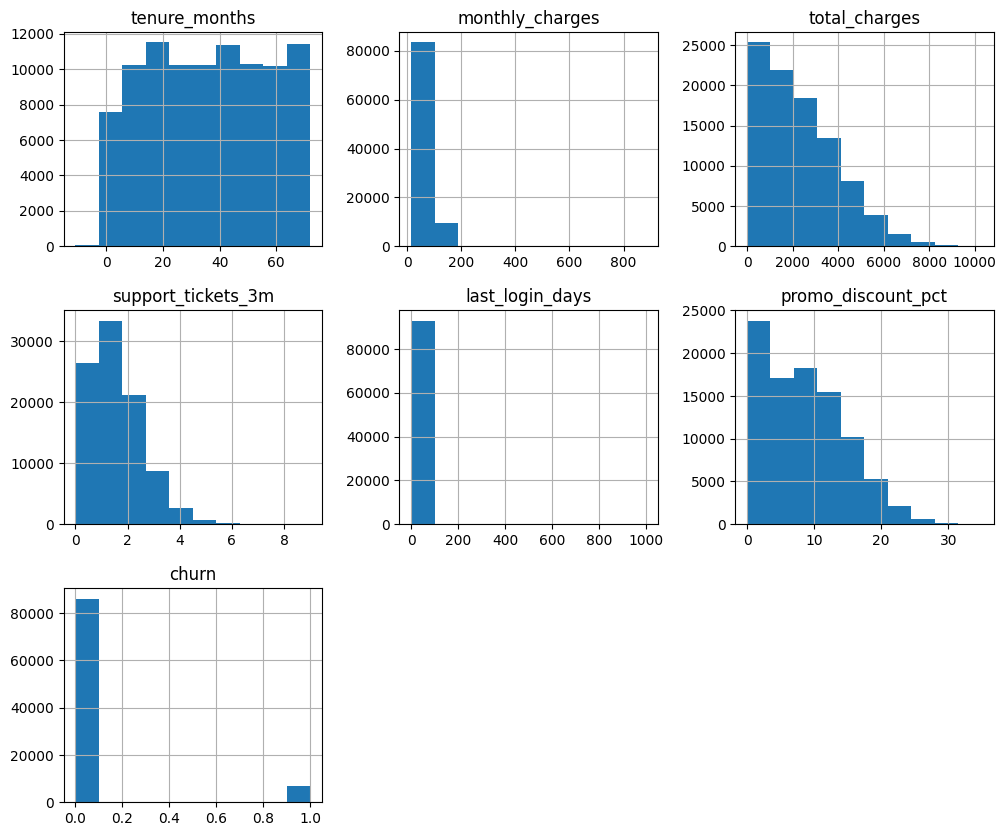

In [128]:
df.hist(figsize=(12,10))

<Axes: xlabel='churn', ylabel='count'>

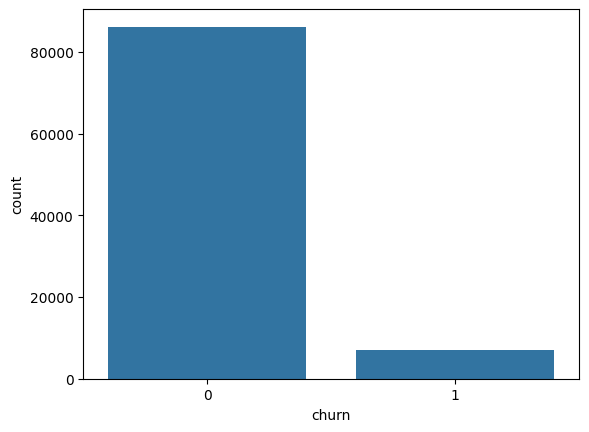

In [130]:
sns.countplot(x='churn',data=df)

In [133]:
nums_cols=df.select_dtypes(include=['int64','float64']).columns

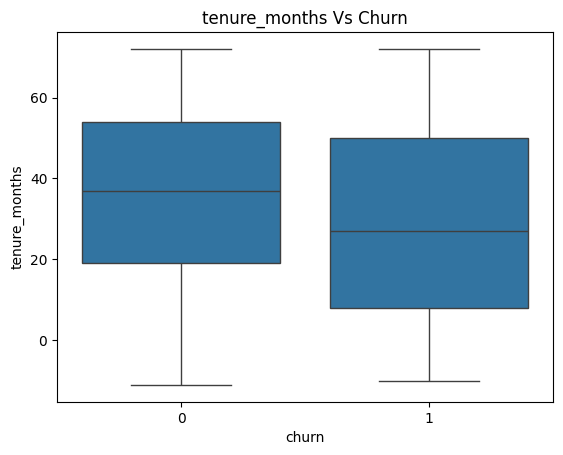

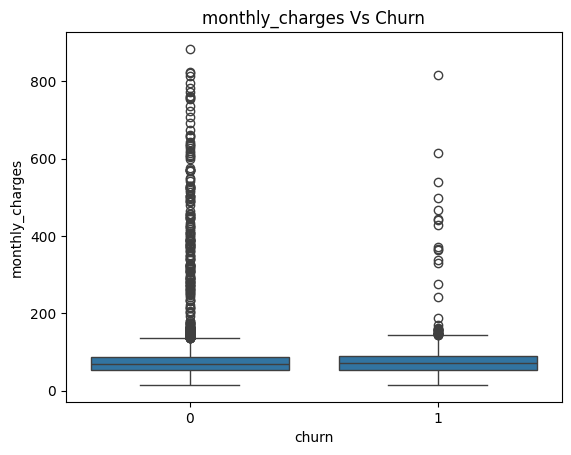

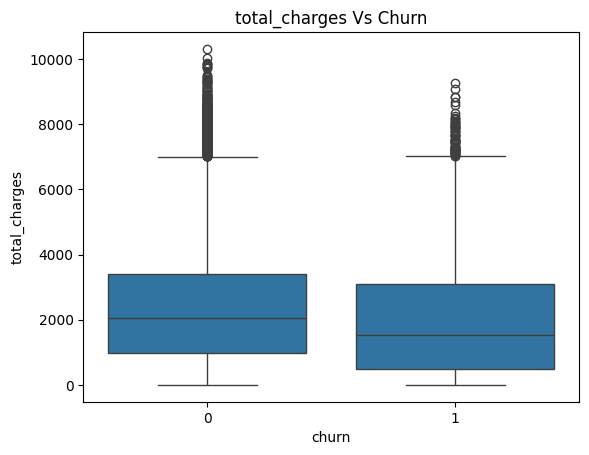

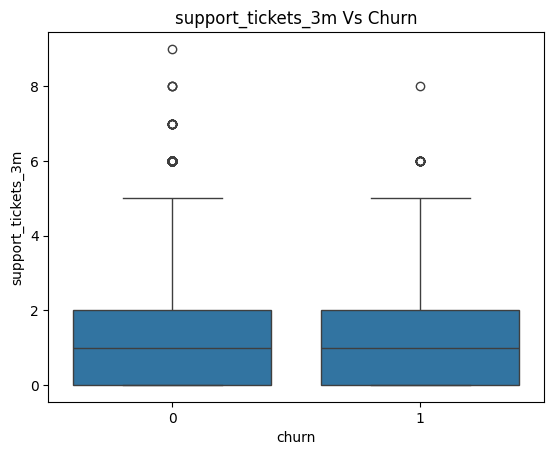

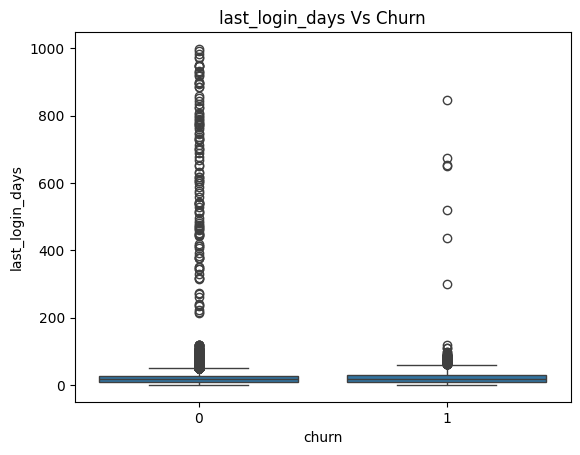

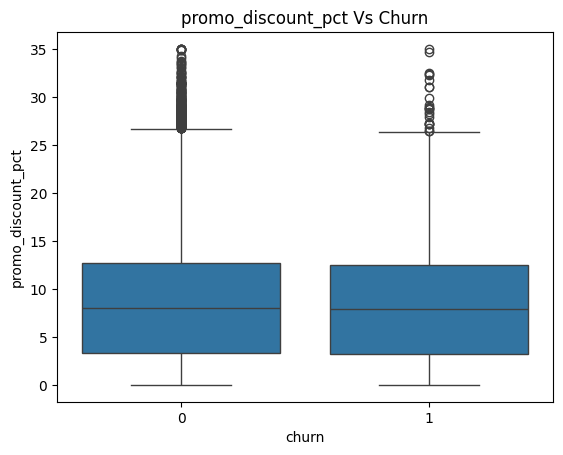

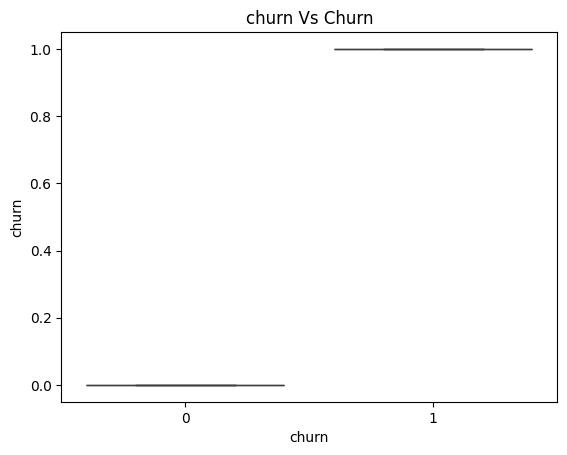

In [137]:
for col in nums_cols:
    plt.figure()
    sns.boxplot(x='churn',y=col,data=df)
    plt.title(f"{col} Vs Churn")

In [138]:
#we want to know the coreelation of our numeric columns

<Axes: >

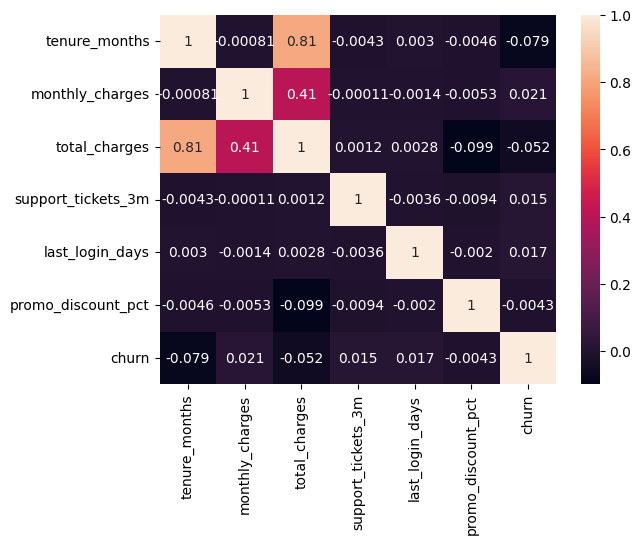

In [139]:
sns.heatmap(df[nums_cols].corr(),annot=True)

# Building our ML pipeline

# Importing the Necessary Libraries

In [196]:
from sklearn import linear_model
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.pipeline import Pipeline,FeatureUnion
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold
from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,confusion_matrix,f1_score,precision_recall_curve
import joblib

# defining our inputs and output

In [143]:
df.head()

,customer_id,tenure_months,monthly_charges,total_charges,contract_type,payment_method,internet_service,support_tickets_3m,last_login_days,promo_discount_pct,churn
0,CUST0000001,6,71.20,450.48,Month-to-month,Electronic check,Fiber optic,1,6.0,8.3,1
1,CUST0000002,56,48.67,2434.29,Two years,Electronic check,DSL,2,6.0,7.3,0
3,CUST0000004,32,74.26,2039.32,Month-to-month,Bank transfer (automatic),Fiber optic,2,3.0,15.8,0
4,CUST0000005,31,64.54,1888.86,Month-to-month,Electronic check,Fiber optic,4,21.0,6.9,0
6,CUST0000007,6,24.69,132.66,Two years,Electronic check,DSL,1,17.0,3.1,0


In [144]:
cats=['contract_type','payment_method','internet_service']

In [147]:
nums=['tenure_months','monthly_charges','support_tickets_3m','last_login_days','promo_discount_pct']

In [149]:
x=df[cats+nums]

In [150]:
x.head()

,contract_type,payment_method,internet_service,tenure_months,monthly_charges,support_tickets_3m,last_login_days,promo_discount_pct
0,Month-to-month,Electronic check,Fiber optic,6,71.20,1,6.0,8.3
1,Two years,Electronic check,DSL,56,48.67,2,6.0,7.3
3,Month-to-month,Bank transfer (automatic),Fiber optic,32,74.26,2,3.0,15.8
4,Month-to-month,Electronic check,Fiber optic,31,64.54,4,21.0,6.9
6,Two years,Electronic check,DSL,6,24.69,1,17.0,3.1


In [151]:
y=df['churn']

# preprocessing and splitting of the data

In [152]:
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.3,random_state=42)

In [153]:
train_x.head()

,contract_type,payment_method,internet_service,tenure_months,monthly_charges,support_tickets_3m,last_login_days,promo_discount_pct
1703,Two years,Electronic check,Fiber optic,14,38.91,1,8.0,2.9
95366,One year,Mailed check,Unknown,3,53.14,2,13.0,0.0
83919,One year,Bank transfer (automatic),DSL,7,100.97,2,20.0,9.2
2005,Month-to-month,Credit card (automatic),Fiber optic,9,37.83,2,33.0,1.7
83755,One year,Electronic check,Fiber optic,43,73.05,1,13.0,0.1


In [163]:
preprocessing=ColumnTransformer([
    ('oht',OneHotEncoder(drop='first'),cats),
    ('std',StandardScaler(),nums)
])


# feature selection and engineering

In [164]:
feature=FeatureUnion([
    ('skt',SelectKBest(score_func=f_classif))
])

# defining our models and ensembling

In [165]:
lgr=linear_model.LogisticRegression()
rf=RandomForestClassifier()
xb=XGBClassifier()

In [166]:
ensemble=VotingClassifier(
    estimators=[('lgr',lgr),
                ('rf',rf),
                ('xb',xb)],
    voting='soft'
)

# building the pipeline

In [168]:
churn_pipeline=Pipeline([
    ('preprocessing',preprocessing),
    ('features',feature),
    ('ensemble',ensemble)
])

In [170]:
strat_kf=StratifiedKFold(n_splits=7,shuffle=True)
scores=cross_val_score(churn_pipeline,train_x,train_y,cv=strat_kf)
print(scores.mean())

0.9266167603366264


In [171]:
strat_kf=StratifiedKFold(n_splits=7,shuffle=True)
scores=cross_val_score(churn_pipeline,train_x,train_y,cv=strat_kf,scoring='f1')
print('f1_score is:',scores.mean())

f1_score is: 0.002910642390791153


In [172]:
strat_kf=StratifiedKFold(n_splits=7,shuffle=True)
scores=cross_val_score(churn_pipeline,train_x,train_y,cv=strat_kf,scoring='recall')
print('Recall is:',scores.mean())

Recall is: 0.0020888605114543313


In [173]:
strat_kf=StratifiedKFold(n_splits=7,shuffle=True)
scores=cross_val_score(churn_pipeline,train_x,train_y,cv=strat_kf,scoring='average_precision')
print('Average Precision:',scores.mean())

Average Precision: 0.12845204708951855


# fitting the model 

In [174]:
churn_pipeline.fit(train_x,train_y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('oht', ...), ('std', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [175]:
y_pred=churn_pipeline.predict(test_x)

In [177]:
print(classification_report(test_y,y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     25780
           1       0.40      0.00      0.00      2160

    accuracy                           0.92     27940
   macro avg       0.66      0.50      0.48     27940
weighted avg       0.88      0.92      0.89     27940



In [178]:
new=test_x.copy()

In [179]:
new['predicted_churn']=y_pred

In [181]:
new.head(50)

,contract_type,payment_method,internet_service,tenure_months,monthly_charges,support_tickets_3m,last_login_days,promo_discount_pct,predicted_churn
16641,Month-to-month,Electronic check,Fiber optic,2,55.69,2,28.0,11.7,0
81620,Month-to-month,Unknown,DSL,40,62.85,0,24.0,0.0,0
21348,Month-to-month,Bank transfer (automatic),Fiber optic,32,63.29,1,15.0,2.4,0
75270,Month-to-month,Mailed check,DSL,8,45.76,1,19.0,7.7,0
90763,Month-to-month,Bank transfer (automatic),Fiber optic,49,98.31,1,24.0,4.2,0
37767,Month-to-month,Credit card (automatic),DSL,42,102.70,0,18.0,0.0,0
74586,Month-to-month,Bank transfer (automatic),DSL,47,121.66,2,32.0,8.4,0
47070,Month-to-month,Credit card (automatic),Fiber optic,51,73.49,5,22.0,12.4,0
86733,Two years,Unknown,DSL,29,36.12,1,17.0,6.3,0
45854,One year,Electronic check,Fiber optic,29,69.14,1,22.0,15.6,0


# Tuning of the threshold

In [185]:
proba=churn_pipeline.predict_proba(test_x)[:,1]

In [190]:
for t in[0.5,0.4,0.3,0.2,0.1]:
    preds=(proba>=t).astype(int)
    print("\nThreshold:",t)
    print(classification_report(test_y,preds))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     25780
           1       0.40      0.00      0.00      2160

    accuracy                           0.92     27940
   macro avg       0.66      0.50      0.48     27940
weighted avg       0.88      0.92      0.89     27940


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     25780
           1       0.30      0.01      0.01      2160

    accuracy                           0.92     27940
   macro avg       0.61      0.50      0.49     27940
weighted avg       0.88      0.92      0.89     27940


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     25780
           1       0.24      0.04      0.06      2160

    accuracy                           0.92     27940
   macro avg       0.58      0.51      0.51     27940
weighted avg       0.87   

In [191]:
for t in[0.15,0.1,0.08,0.06,0.05]:
    preds=(proba>=t).astype(int)
    print("\nThreshold:",t)
    print(classification_report(test_y,preds))


Threshold: 0.15
              precision    recall  f1-score   support

           0       0.93      0.91      0.92     25780
           1       0.17      0.21      0.19      2160

    accuracy                           0.86     27940
   macro avg       0.55      0.56      0.55     27940
weighted avg       0.87      0.86      0.86     27940


Threshold: 0.1
              precision    recall  f1-score   support

           0       0.94      0.80      0.86     25780
           1       0.13      0.38      0.20      2160

    accuracy                           0.76     27940
   macro avg       0.54      0.59      0.53     27940
weighted avg       0.88      0.76      0.81     27940


Threshold: 0.08
              precision    recall  f1-score   support

           0       0.94      0.71      0.81     25780
           1       0.12      0.49      0.20      2160

    accuracy                           0.69     27940
   macro avg       0.53      0.60      0.50     27940
weighted avg       0.88 

In [192]:
final_threshold=0.08

In [194]:
proba=churn_pipeline.predict_proba(test_x)[:,1]
final_preds=(proba>=final_threshold).astype(int)

In [195]:
print(classification_report(test_y,final_preds))

              precision    recall  f1-score   support

           0       0.94      0.71      0.81     25780
           1       0.12      0.49      0.20      2160

    accuracy                           0.69     27940
   macro avg       0.53      0.60      0.50     27940
weighted avg       0.88      0.69      0.76     27940



# saving the model and the threshold

In [197]:
joblib.dump(churn_pipeline,"churn_pipeline.pkl")
joblib.dump(final_threshold,"final_threshold.pkl")

['final_threshold.pkl']

In [198]:
joblib.dump(churn_pipeline,"churn_pipeline.pkl")

['churn_pipeline.pkl']